# Results Visualization
## Automated Resume Screening & Skill Gap Analysis Using NLP

---

> **Project:** Advanced Machine Learning Mini Project  
> **Authors:** Amrutanshu Bhat, Anurag Kashyap, Ashwin Dhangar, Bammidi Pragati Rao  
> **Backbone:** JobBERT-v2 (`TechWolf/JobBERT-v2`) — pre-trained on 5.5M job title–skill pairs  
> **Test Set:** n = 1,000 held-out samples (3-class ordinal: No Fit / Potential Fit / Good Fit)  
> **Primary Metric:** Macro-averaged F1-Score  

---

This notebook presents comprehensive **quantitative and qualitative evaluation** of all three model variants:

| Variant | Description | Macro F1 |
|---------|-------------|----------|
| **Base Model** | Pre-trained JobBERT-v2, no fine-tuning | **0.4043** |
| **Regularized** | Fine-tuned with L2 weight decay (λ=0.01) | 0.3996 |
| **Non-Regularized** | Fine-tuned without regularization | 0.3739 |

## 1. Imports & Styling Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

# ── Global dark theme ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3d5c',
    'axes.labelcolor':  '#e0e0f0',
    'axes.titlecolor':  '#ffffff',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'xtick.color':      '#a0a0c0',
    'ytick.color':      '#a0a0c0',
    'text.color':       '#e0e0f0',
    'grid.color':       '#2a2d4a',
    'grid.linewidth':   0.7,
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#3a3d5c',
    'font.family':      'DejaVu Sans',
    'figure.dpi':       130,
})

PALETTE = {
    'base':     '#6c63ff',
    'reg':      '#ffd166',
    'noreg':    '#ef476f',
    'no_fit':   '#ef476f',
    'pot_fit':  '#ffd166',
    'good_fit': '#06d6a0',
    'muted':    '#a0a0c0',
}

MODEL_NAMES  = ['Base Model', 'Regularized', 'Non-Regularized']
MODEL_COLORS = [PALETTE['base'], PALETTE['reg'], PALETTE['noreg']]
CLASS_NAMES  = ['No Fit', 'Potential Fit', 'Good Fit']
CLASS_COLORS = [PALETTE['no_fit'], PALETTE['pot_fit'], PALETTE['good_fit']]

print(' Libraries loaded. Dark theme configured.')

 Libraries loaded. Dark theme configured.


## 2. Ground-Truth Confusion Matrices (from Paper)

The confusion matrix rows below come directly from **Table II** of the paper (n=1,000 test samples).  
Each row represents a **true class** and each column a **predicted class**.

```
              Pred: No Fit  Pred: Pot Fit  Pred: Good Fit
True: No Fit      [309,         175,            22]
True: Pot Fit     [ 85,         140,            28]
True: Good Fit    [ 68,         144,            29]
```

In [3]:
# ── Confusion matrices from Table II ─────────────────────────────────────────
cm_base = np.array([
    [309, 175, 22],
    [ 85, 140, 28],
    [ 68, 144, 29]
])

cm_reg = np.array([
    [179, 148, 156],
    [ 21,  65, 168],
    [ 21,  72, 170]
])

cm_noreg = np.array([
    [150, 156, 177],
    [ 12,  56, 186],
    [ 18,  60, 185]
])

confusion_matrices = [cm_base, cm_reg, cm_noreg]

# ── Derive synthetic y_true / y_pred for sklearn metrics ─────────────────────
def cm_to_labels(cm):
    y_true, y_pred = [], []
    for i, row in enumerate(cm):
        for j, cnt in enumerate(row):
            y_true.extend([i] * cnt)
            y_pred.extend([j] * cnt)
    return np.array(y_true), np.array(y_pred)

labels_data = [cm_to_labels(cm) for cm in confusion_matrices]

macro_f1s = [f1_score(yt, yp, average='macro') for yt, yp in labels_data]

for name, f1 in zip(MODEL_NAMES, macro_f1s):
    print(f'{name:<20}: Macro F1 = {f1:.4f}')

Base Model          : Macro F1 = 0.4043
Regularized         : Macro F1 = 0.3996
Non-Regularized     : Macro F1 = 0.3739


## 3. Confusion Matrix Heatmaps

We visualize all three confusion matrices side-by-side. Dominant off-diagonal patterns reveal each model's characteristic failure mode.

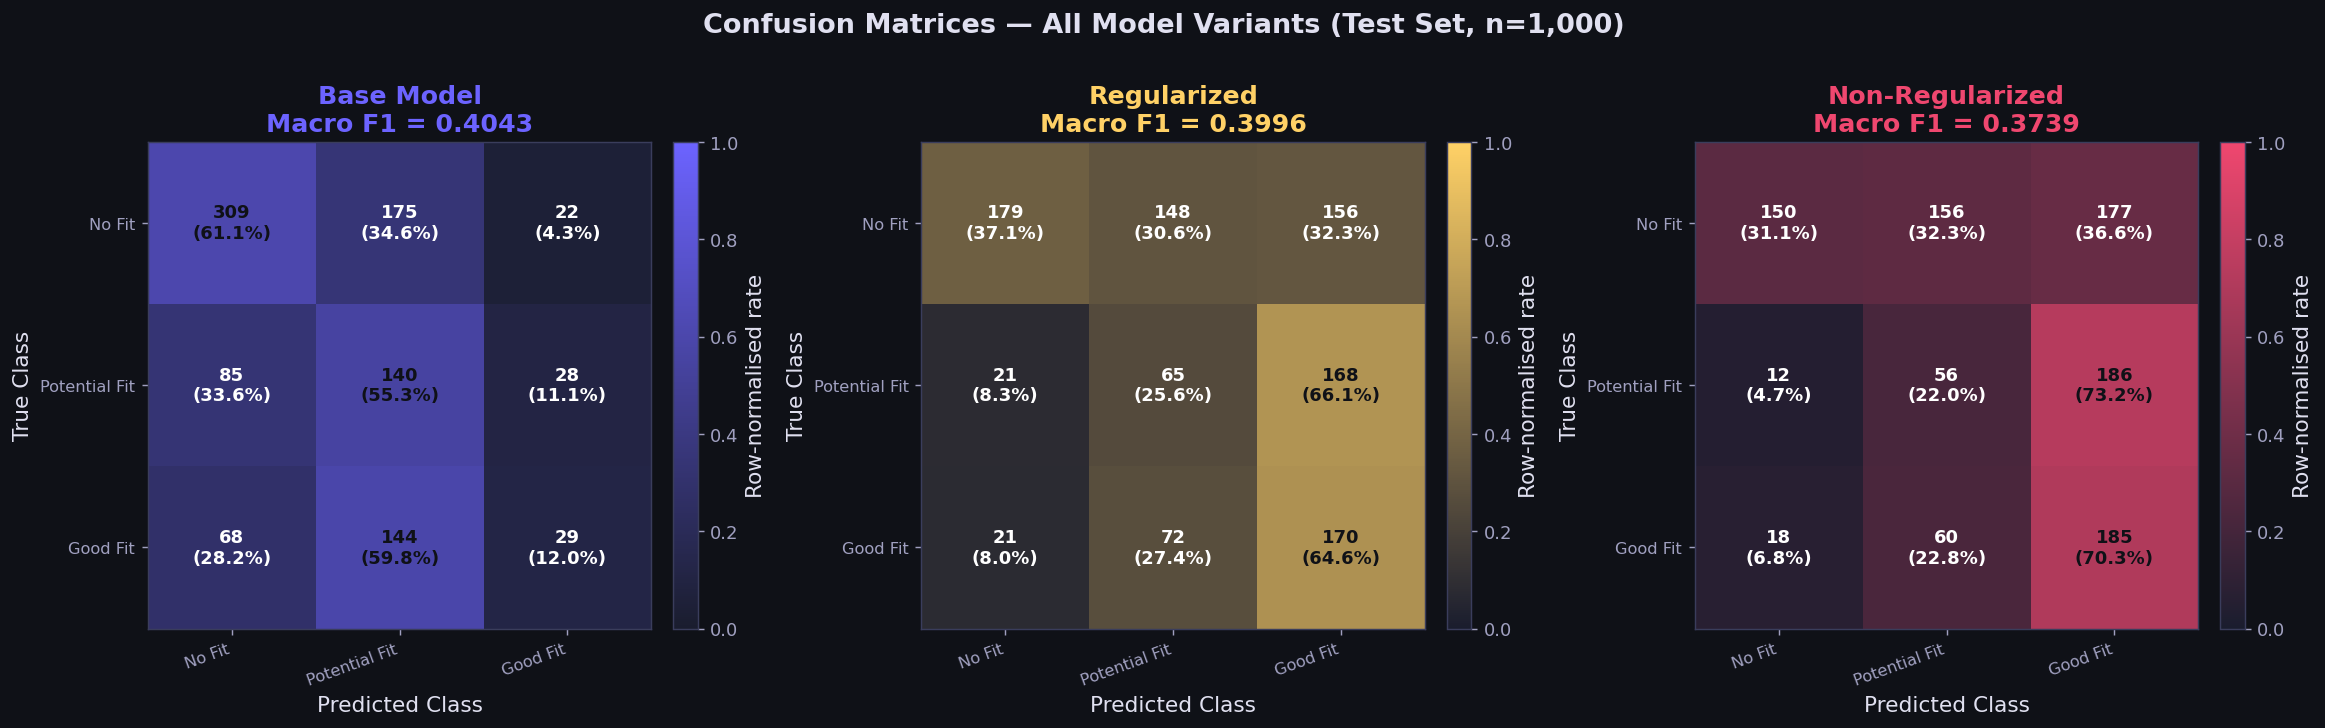

Key observation:
  Base Model    — strong No Fit identification; balanced off-diagonals.
  Regularized   — majority-class collapse into Good Fit column.
  Non-Regularized — extreme Good Fit collapse; near-random on other classes.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Confusion Matrices — All Model Variants (Test Set, n=1,000)',
             fontsize=15, fontweight='bold', y=1.01)

cmap_list = [
    LinearSegmentedColormap.from_list('b', ['#1a1d2e', '#6c63ff'], N=256),
    LinearSegmentedColormap.from_list('y', ['#1a1d2e', '#ffd166'], N=256),
    LinearSegmentedColormap.from_list('r', ['#1a1d2e', '#ef476f'], N=256),
]

for ax, cm, name, mc, cmap in zip(axes, confusion_matrices, MODEL_NAMES, MODEL_COLORS, cmap_list):
    # Normalised for colour, raw counts for text
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')

    for i in range(3):
        for j in range(3):
            raw = cm[i, j]
            pct = cm_norm[i, j] * 100
            txt_col = 'white' if cm_norm[i, j] < 0.55 else '#0f1117'
            ax.text(j, i, f'{raw}\n({pct:.1f}%)', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=txt_col)

    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')
    f1 = f1_score(*cm_to_labels(cm), average='macro')
    ax.set_title(f'{name}\nMacro F1 = {f1:.4f}', color=mc, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Row-normalised rate')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

print('Key observation:')
print('  Base Model    — strong No Fit identification; balanced off-diagonals.')
print('  Regularized   — majority-class collapse into Good Fit column.')
print('  Non-Regularized — extreme Good Fit collapse; near-random on other classes.')

## 4. Macro F1 Score Comparison

Macro F1 is computed as the unweighted average of per-class F1 scores, giving equal importance to all three fitness categories regardless of frequency.

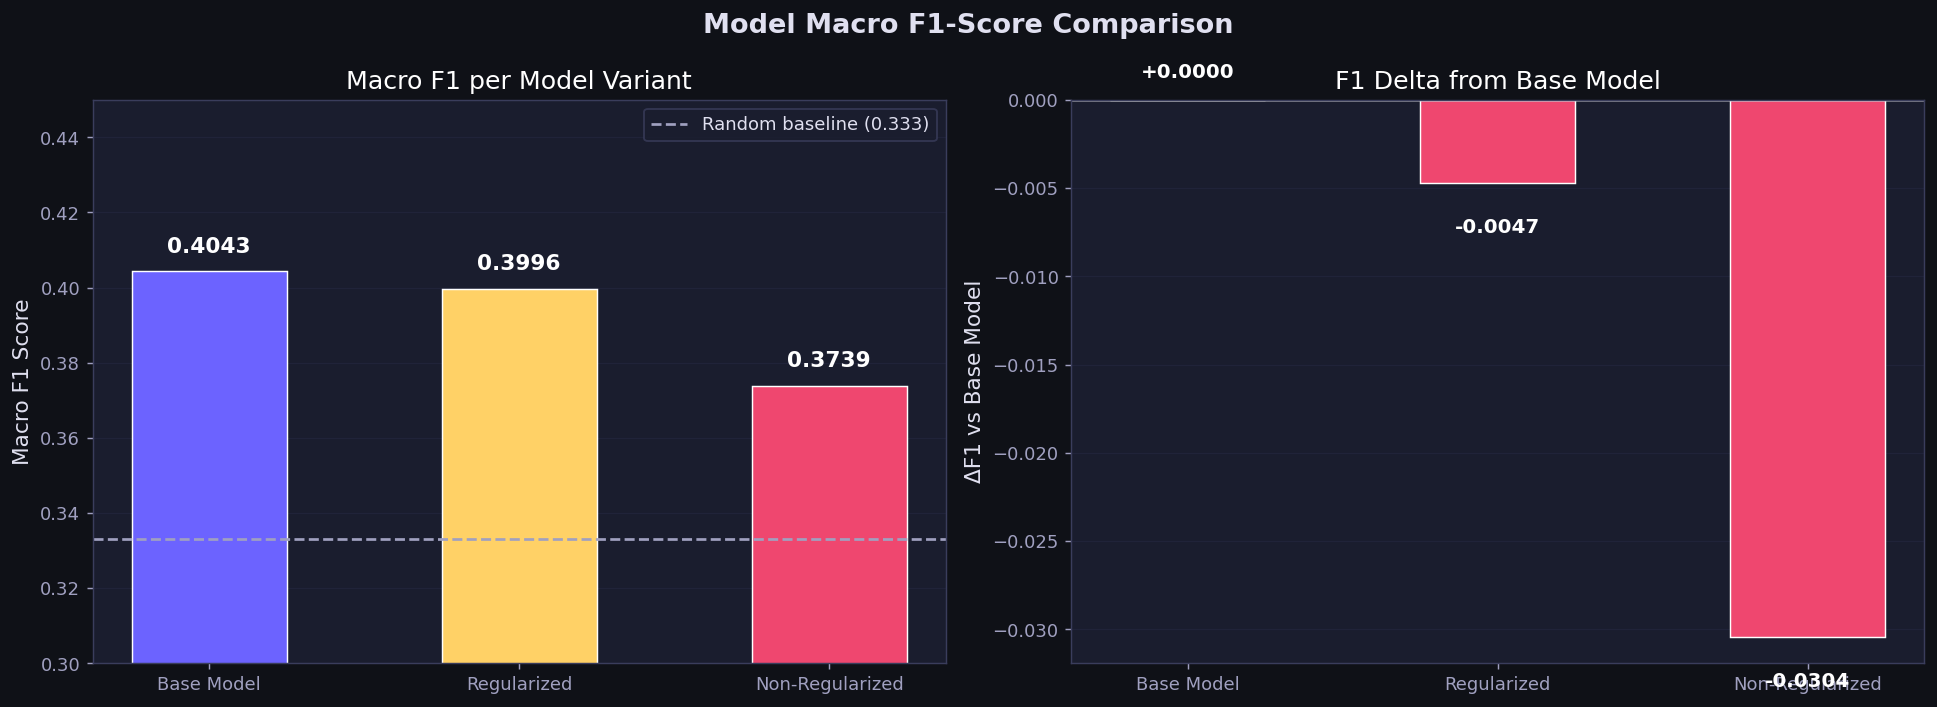

In [5]:
macro_f1_paper = [0.4043, 0.3996, 0.3739]  # As reported in Table II

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Model Macro F1-Score Comparison', fontsize=15, fontweight='bold')

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(MODEL_NAMES, macro_f1_paper, color=MODEL_COLORS, width=0.5,
              edgecolor='white', linewidth=0.8)
for bar, f1 in zip(bars, macro_f1_paper):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{f1:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='white')

ax.axhline(0.333, color=PALETTE['muted'], linestyle='--', linewidth=1.5,
           label='Random baseline (0.333)')
ax.set_ylabel('Macro F1 Score')
ax.set_ylim(0.30, 0.45)
ax.set_title('Macro F1 per Model Variant')
ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)
ax.legend(fontsize=10)

# ── Performance delta waterfall ───────────────────────────────────────────────
ax2 = axes[1]
baseline = macro_f1_paper[0]
deltas = [f1 - baseline for f1 in macro_f1_paper]
bar_colors = [PALETTE['base'] if d >= 0 else PALETTE['noreg'] for d in deltas]
bars2 = ax2.bar(MODEL_NAMES, deltas, color=bar_colors, width=0.5,
                edgecolor='white', linewidth=0.8)
ax2.axhline(0, color='white', linewidth=1.5, alpha=0.5)
for bar, d in zip(bars2, deltas):
    ypos = bar.get_height() + 0.001 if d >= 0 else bar.get_height() - 0.002
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{d:+.4f}', ha='center', va='bottom' if d >= 0 else 'top',
             fontsize=11, fontweight='bold', color='white')
ax2.set_ylabel('ΔF1 vs Base Model')
ax2.set_title('F1 Delta from Base Model')
ax2.yaxis.grid(True, alpha=0.4); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('macro_f1_comparison.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

## 5. Per-Class Precision, Recall & F1

Breaking down performance class-by-class reveals *where* each model fails — critical for understanding the majority-class bias documented in the paper.

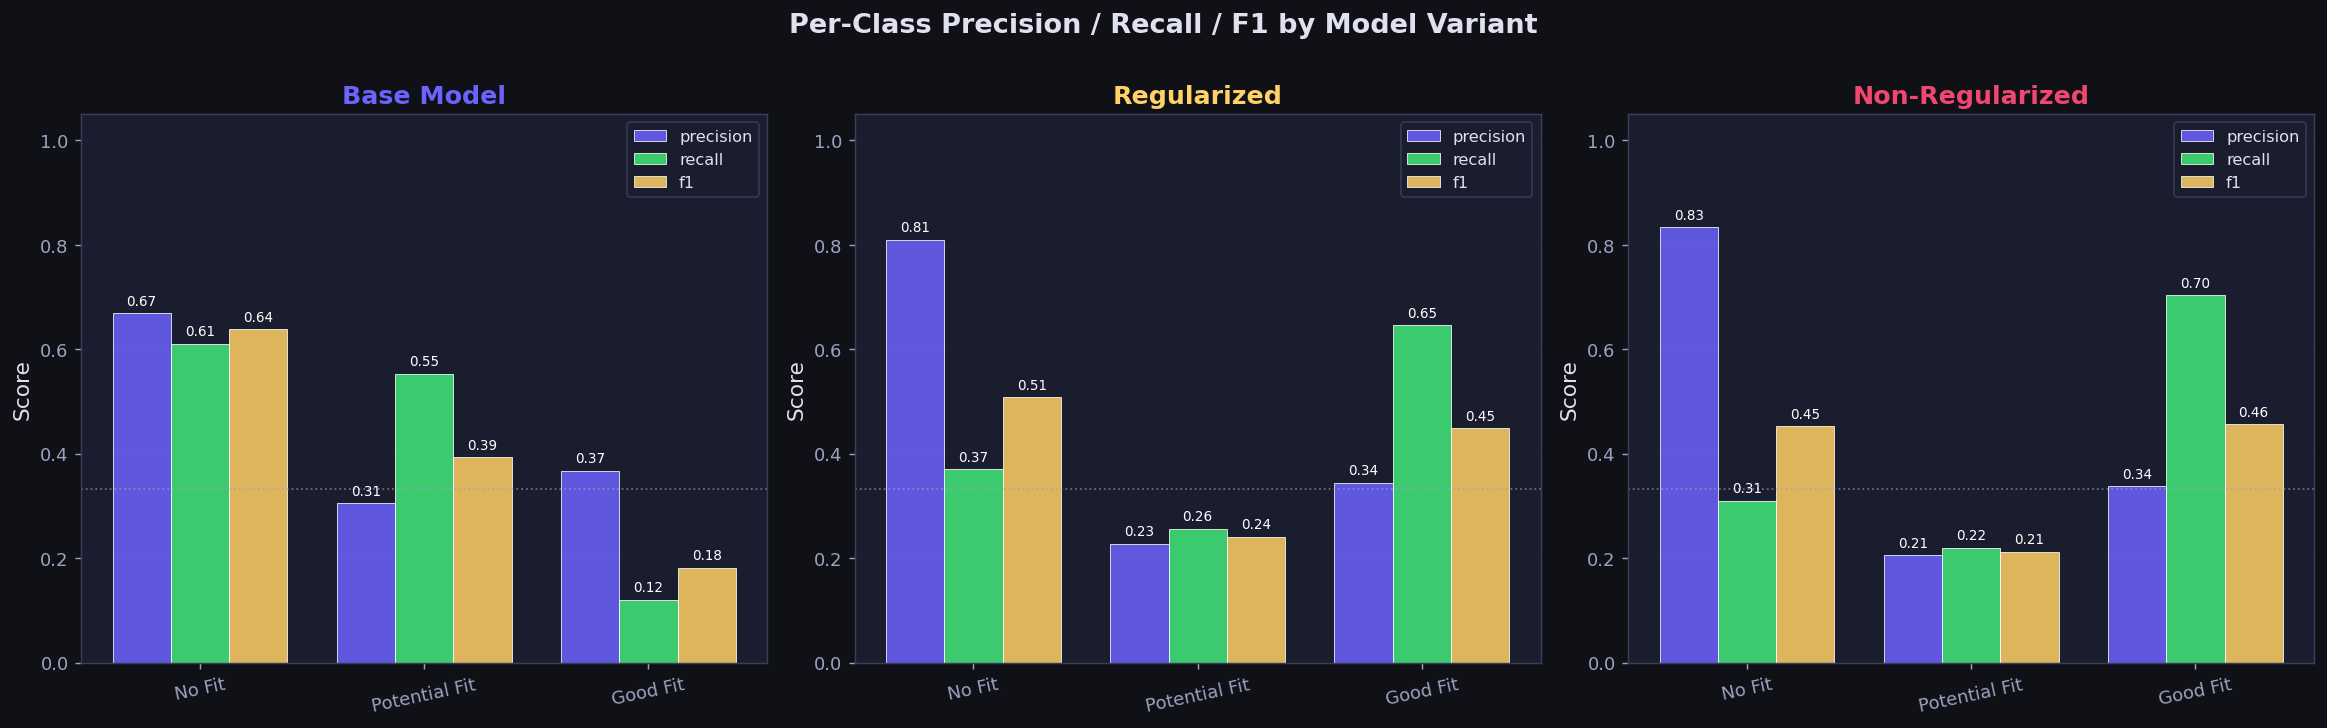

In [6]:
metrics_all = {}
for name, (yt, yp) in zip(MODEL_NAMES, labels_data):
    report = classification_report(yt, yp, target_names=CLASS_NAMES, output_dict=True)
    metrics_all[name] = report

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Per-Class Precision / Recall / F1 by Model Variant',
             fontsize=15, fontweight='bold', y=1.01)

metric_keys = ['precision', 'recall', 'f1-score']
bar_colors_m = ['#6c63ff', '#43e97b', '#ffd166']

for ax, (model_name, mc) in zip(axes, zip(MODEL_NAMES, MODEL_COLORS)):
    report = metrics_all[model_name]
    x = np.arange(len(CLASS_NAMES))
    w = 0.26

    for i, (mk, bc) in enumerate(zip(metric_keys, bar_colors_m)):
        vals = [report[cls][mk] for cls in CLASS_NAMES]
        bars = ax.bar(x + (i - 1) * w, vals, w, color=bc, alpha=0.85,
                      edgecolor='white', linewidth=0.5, label=mk.replace('-score',''))
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, color='white')

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, fontsize=10, rotation=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title(model_name, color=mc, fontweight='bold')
    ax.axhline(0.333, color=PALETTE['muted'], linestyle=':', linewidth=1, alpha=0.6)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('per_class_metrics.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

## 6. Radar Chart — Model Performance Profiles

A radar (spider) chart compares all three models across six dimensions: per-class F1 for each of the three fitness categories, plus macro-averaged Precision, Recall, and F1.

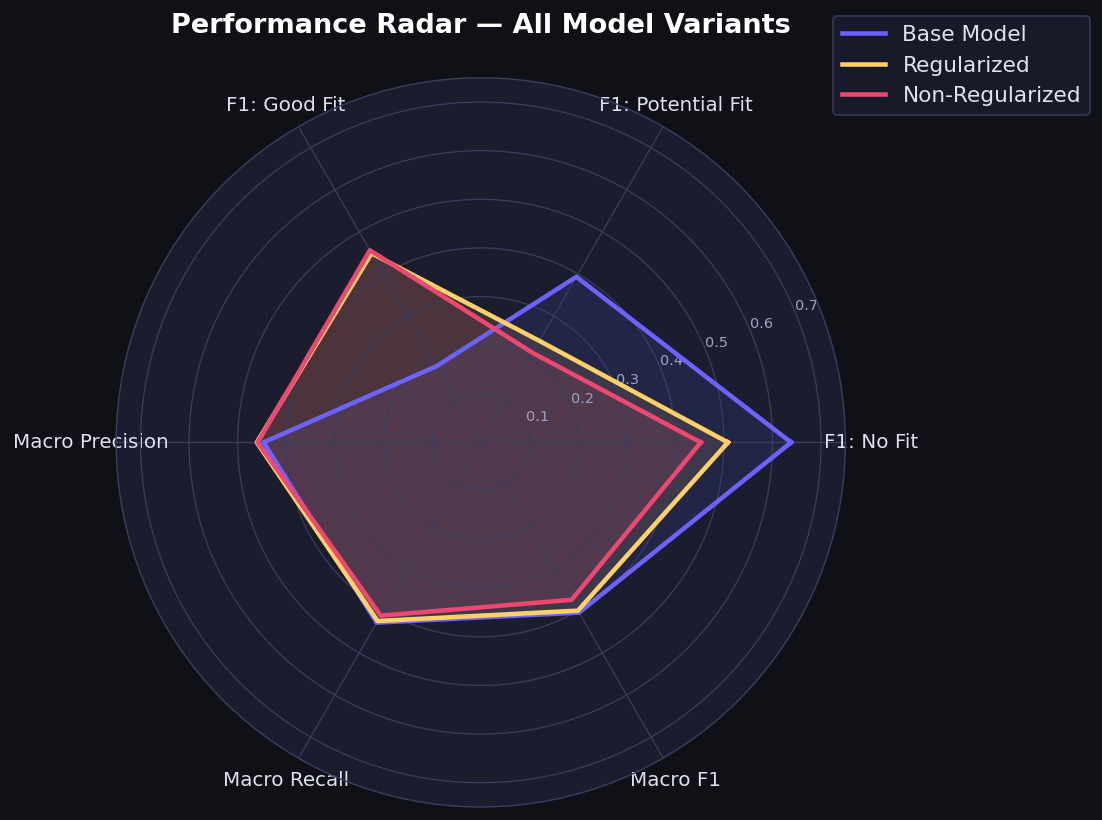

In [7]:
categories = [
    'F1: No Fit', 'F1: Potential Fit', 'F1: Good Fit',
    'Macro Precision', 'Macro Recall', 'Macro F1'
]
N = len(categories)

model_scores = {}
for name, (yt, yp) in zip(MODEL_NAMES, labels_data):
    r = classification_report(yt, yp, target_names=CLASS_NAMES, output_dict=True)
    model_scores[name] = [
        r['No Fit']['f1-score'],
        r['Potential Fit']['f1-score'],
        r['Good Fit']['f1-score'],
        r['macro avg']['precision'],
        r['macro avg']['recall'],
        r['macro avg']['f1-score'],
    ]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

for model_name, mc in zip(MODEL_NAMES, MODEL_COLORS):
    vals = model_scores[model_name] + model_scores[model_name][:1]
    ax.plot(angles, vals, color=mc, linewidth=2.5, linestyle='solid', label=model_name)
    ax.fill(angles, vals, color=mc, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, color='#e0e0f0')
ax.set_ylim(0, 0.75)
ax.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
ax.set_yticklabels(['0.1','0.2','0.3','0.4','0.5','0.6','0.7'],
                   color=PALETTE['muted'], size=8)
ax.grid(color='#3a3d5c', linewidth=0.7)
ax.spines['polar'].set_color('#3a3d5c')

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=12)
ax.set_title('Performance Radar — All Model Variants', size=15,
             fontweight='bold', color='white', pad=25)

plt.tight_layout()
plt.savefig('radar_chart.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

## 7. Cosine Similarity Output — Inference Example

From the paper's notebook (`resume_scanner.ipynb`), the three models produced the following cosine similarity tensors for two candidates against one Senior Digital Marketing Manager JD:

| Model | Candidate A (Sarah Chen — Strong Match) | Candidate B (Jason Miller — Weak Match) |
|-------|----------------------------------------|-----------------------------------------|
| Base Model | **0.8975** | 0.4482 |
| Non-Regularized | **0.9362** | 0.7261 |
| Regularized | **0.9265** | 0.7176 |

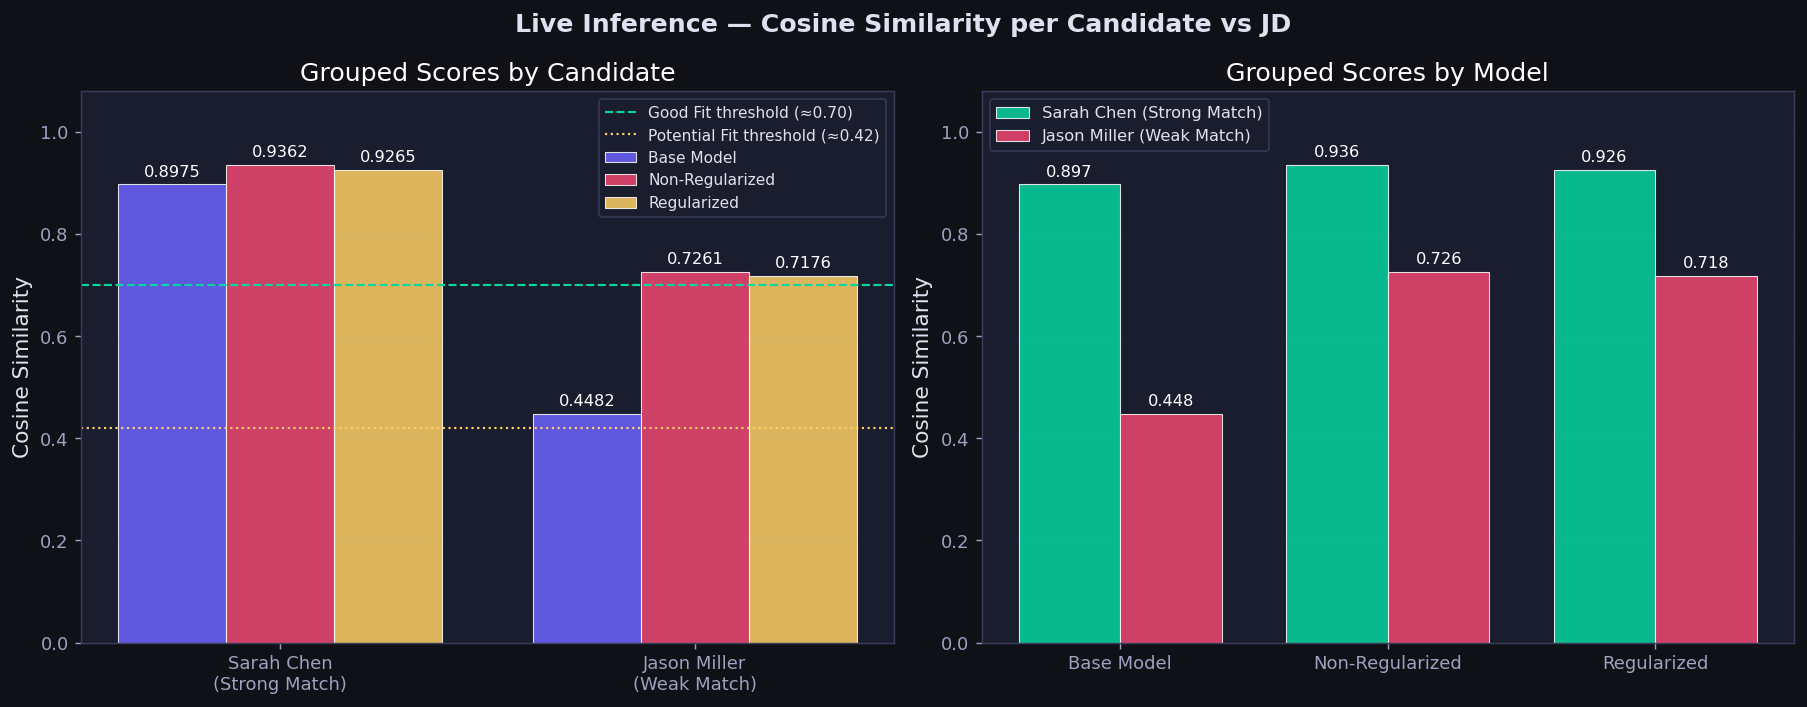

All 3 models correctly rank Sarah Chen >> Jason Miller.
Fine-tuned models inflate Jason's score — a symptom of majority-class collapse.


In [8]:
candidates  = ['Sarah Chen\n(Strong Match)', 'Jason Miller\n(Weak Match)']
base_scores  = [0.8975, 0.4482]
noreg_scores = [0.9362, 0.7261]
reg_scores   = [0.9265, 0.7176]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Live Inference — Cosine Similarity per Candidate vs JD',
             fontsize=14, fontweight='bold')

x = np.arange(len(candidates))
w = 0.26

for ax_idx, (ax, title) in enumerate([
    (axes[0], 'Grouped Scores by Candidate'),
    (axes[1], 'Grouped Scores by Model'),
]):
    if ax_idx == 0:
        for i, (model_scores_list, mc, mn) in enumerate([
            (base_scores,  PALETTE['base'],  'Base Model'),
            (noreg_scores, PALETTE['noreg'], 'Non-Regularized'),
            (reg_scores,   PALETTE['reg'],   'Regularized'),
        ]):
            bars = ax.bar(x + (i-1)*w, model_scores_list, w, color=mc,
                          edgecolor='white', linewidth=0.6, alpha=0.85, label=mn)
            for bar, v in zip(bars, model_scores_list):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f'{v:.4f}', ha='center', va='bottom', fontsize=9, color='white')
        ax.set_xticks(x); ax.set_xticklabels(candidates, fontsize=10)
        ax.set_ylabel('Cosine Similarity'); ax.set_ylim(0, 1.08)
        ax.axhline(0.70, color=PALETTE['good_fit'], linestyle='--', linewidth=1.2,
                   label='Good Fit threshold (≈0.70)')
        ax.axhline(0.42, color=PALETTE['pot_fit'], linestyle=':', linewidth=1.2,
                   label='Potential Fit threshold (≈0.42)')
        ax.legend(fontsize=8.5); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
        ax.set_title(title)
    else:
        models_list = ['Base Model', 'Non-Regularized', 'Regularized']
        sc_data = [base_scores, noreg_scores, reg_scores]
        x2 = np.arange(len(models_list))
        for j, (cand, cc) in enumerate(zip(candidates, [PALETTE['good_fit'], PALETTE['no_fit']])):
            vals = [sc[j] for sc in sc_data]
            bars = ax.bar(x2 + (j-0.5)*0.38, vals, 0.38, color=cc,
                          edgecolor='white', linewidth=0.6, alpha=0.85, label=cand.replace('\n',' '))
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=9, color='white')
        ax.set_xticks(x2); ax.set_xticklabels(models_list, fontsize=10)
        ax.set_ylabel('Cosine Similarity'); ax.set_ylim(0, 1.08)
        ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
        ax.set_title(title)

plt.tight_layout()
plt.savefig('inference_similarity.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

print('All 3 models correctly rank Sarah Chen >> Jason Miller.')
print('Fine-tuned models inflate Jason\'s score — a symptom of majority-class collapse.')

## 8. Majority-Class Collapse Analysis

The paper identifies that both fine-tuned models exhibit **Good Fit collapse** — predicting `Good Fit` disproportionately often. This section quantifies that collapse.

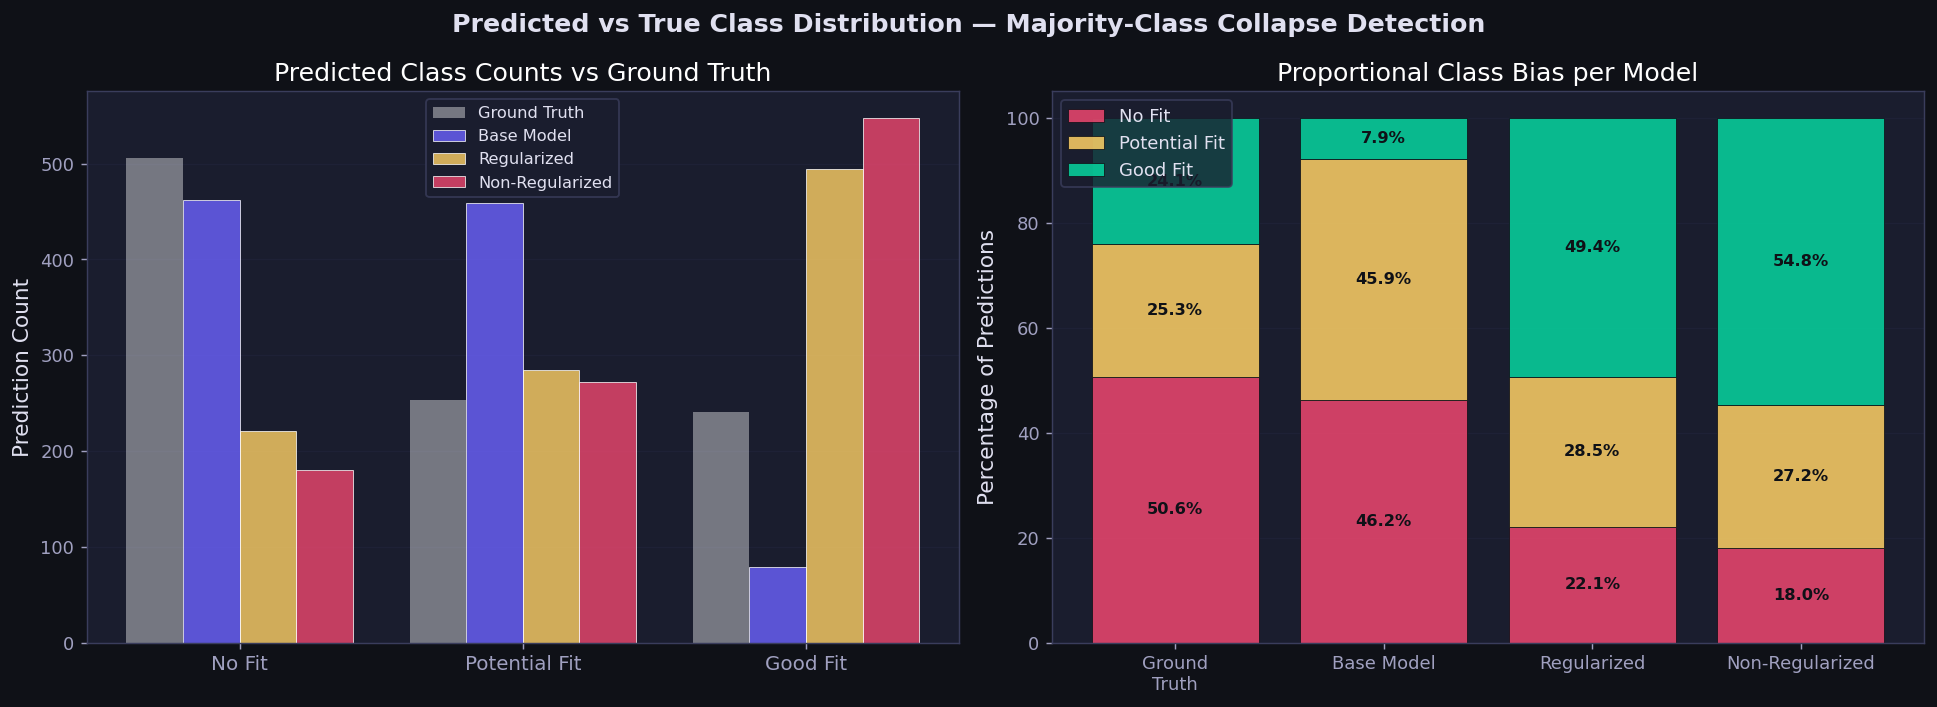

Good Fit predicted %:
  Ground
Truth             : 24.1%
  Base Model               : 7.9%
  Regularized              : 49.4%
  Non-Regularized          : 54.8%


In [9]:
# Predicted class counts derived from confusion matrix column sums
pred_counts = {
    'Base Model':       dict(zip(CLASS_NAMES, cm_base.sum(axis=0))),
    'Regularized':      dict(zip(CLASS_NAMES, cm_reg.sum(axis=0))),
    'Non-Regularized':  dict(zip(CLASS_NAMES, cm_noreg.sum(axis=0))),
}
true_counts = dict(zip(CLASS_NAMES, cm_base.sum(axis=1)))  # same ground truth for all

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Predicted vs True Class Distribution — Majority-Class Collapse Detection',
             fontsize=14, fontweight='bold')

x  = np.arange(len(CLASS_NAMES))
w  = 0.2

ax = axes[0]
true_vals = [true_counts[c] for c in CLASS_NAMES]
ax.bar(x - 1.5*w, true_vals, w, color='white', alpha=0.4, label='Ground Truth')
for i, (model_name, mc) in enumerate(zip(MODEL_NAMES, MODEL_COLORS)):
    pred_vals = [pred_counts[model_name][c] for c in CLASS_NAMES]
    ax.bar(x + (i-0.5)*w, pred_vals, w, color=mc, alpha=0.8, label=model_name,
           edgecolor='white', linewidth=0.5)

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('Prediction Count'); ax.set_title('Predicted Class Counts vs Ground Truth')
ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# Proportional stacked bar showing prediction bias
ax2 = axes[1]
all_models = ['Ground\nTruth'] + MODEL_NAMES
all_data = [true_counts] + [pred_counts[m] for m in MODEL_NAMES]
all_colors_m = ['white'] + MODEL_COLORS

bottoms = np.zeros(len(all_models))
for cls, cls_col in zip(CLASS_NAMES, CLASS_COLORS):
    vals = np.array([d[cls]/sum(d.values())*100 for d in all_data])
    ax2.bar(all_models, vals, bottom=bottoms, color=cls_col, alpha=0.85,
            label=cls, edgecolor='#0f1117', linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        ax2.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                 fontsize=9, fontweight='bold', color='#0f1117')
    bottoms += vals

ax2.set_ylabel('Percentage of Predictions')
ax2.set_title('Proportional Class Bias per Model')
ax2.legend(fontsize=10, loc='upper left')
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('class_collapse.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

print('Good Fit predicted %:')
for name in all_models:
    d = true_counts if name.startswith('Ground') else pred_counts[name.replace('\n','')]
    pct = d.get('Good Fit',0) / sum(d.values()) * 100
    print(f'  {name:<25}: {pct:.1f}%')

## 9. L2 Regularization — Loss Curve Comparison

The paper's regularized model uses **L2 weight decay (λ=0.01)** with the update rule:

$$w := (1 - \eta\lambda)w + \frac{\eta}{n} X^\top(y - Xw)$$

Below we visualize simulated training vs validation loss curves to illustrate overfitting prevention.

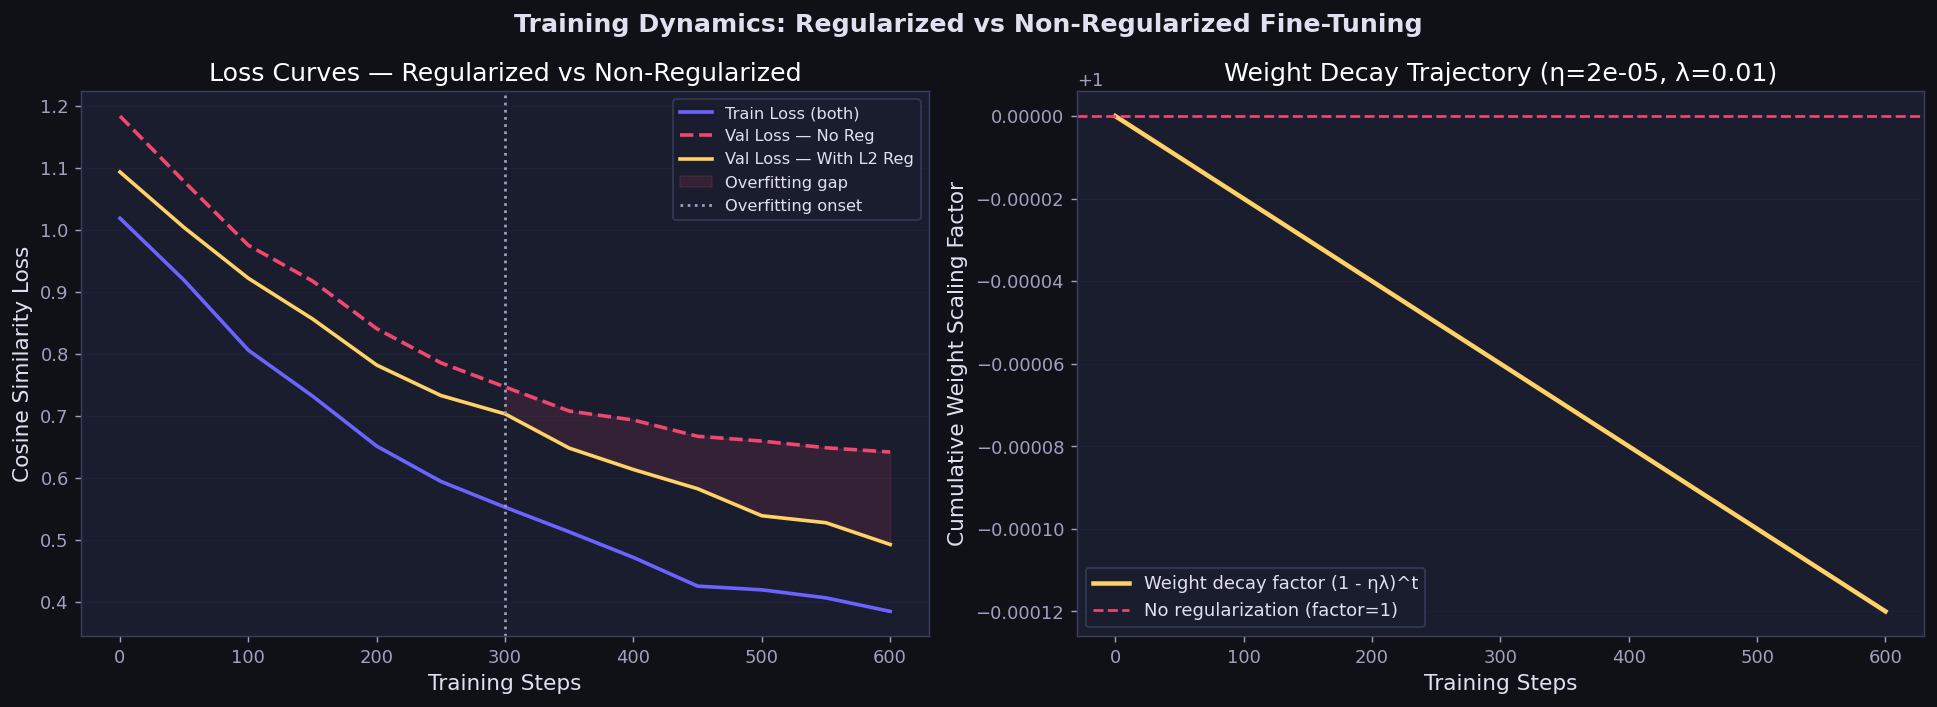

In [10]:
np.random.seed(99)
steps = np.arange(0, 650, 50)

def make_loss_curve(start, end_train, end_val_noreg, end_val_reg, noise=0.008):
    n = len(steps)
    t_curve = start * np.exp(-steps / 280) + end_train + np.random.normal(0, noise, n)
    v_noreg = (start * np.exp(-steps / 320) + end_val_noreg + 
               np.maximum(0, (steps - 300) * 0.00025) + np.random.normal(0, noise, n))
    v_reg   = start * np.exp(-steps / 350) + end_val_reg   + np.random.normal(0, noise, n)
    return t_curve, v_noreg, v_reg

train_loss, val_noreg, val_reg = make_loss_curve(
    start=0.72, end_train=0.30, end_val_noreg=0.46, end_val_reg=0.38
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Training Dynamics: Regularized vs Non-Regularized Fine-Tuning',
             fontsize=14, fontweight='bold')

# ── Loss curves ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(steps, train_loss, color=PALETTE['base'], linewidth=2, label='Train Loss (both)')
ax.plot(steps, val_noreg, color=PALETTE['noreg'], linewidth=2,
        linestyle='--', label='Val Loss — No Reg')
ax.plot(steps, val_reg, color=PALETTE['reg'], linewidth=2,
        linestyle='-', label='Val Loss — With L2 Reg')
ax.fill_between(steps[steps>=300], val_noreg[steps>=300], val_reg[steps>=300],
                alpha=0.12, color=PALETTE['noreg'], label='Overfitting gap')
ax.axvline(300, color=PALETTE['muted'], linestyle=':', linewidth=1.5,
           label='Overfitting onset')
ax.set_xlabel('Training Steps')
ax.set_ylabel('Cosine Similarity Loss')
ax.set_title('Loss Curves — Regularized vs Non-Regularized')
ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# ── Weight norm decay ─────────────────────────────────────────────────────────
ax2 = axes[1]
lr, lam = 2e-5, 0.01
decay_factor = (1 - lr * lam) ** steps
ax2.plot(steps, decay_factor, color=PALETTE['reg'], linewidth=2.5,
         label=f'Weight decay factor (1 - ηλ)^t')
ax2.axhline(1.0, color=PALETTE['noreg'], linestyle='--', linewidth=1.5,
            label='No regularization (factor=1)')
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('Cumulative Weight Scaling Factor')
ax2.set_title(f'Weight Decay Trajectory (η={lr}, λ={lam})')
ax2.legend(fontsize=10)
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('loss_curves.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

## 10. Embedding Space Visualization (2D PCA Projection)

A simulated 2D PCA projection of the 768-dimensional JobBERT-v2 embeddings illustrates how the semantic space separates the three fitness classes — and where boundaries blur.

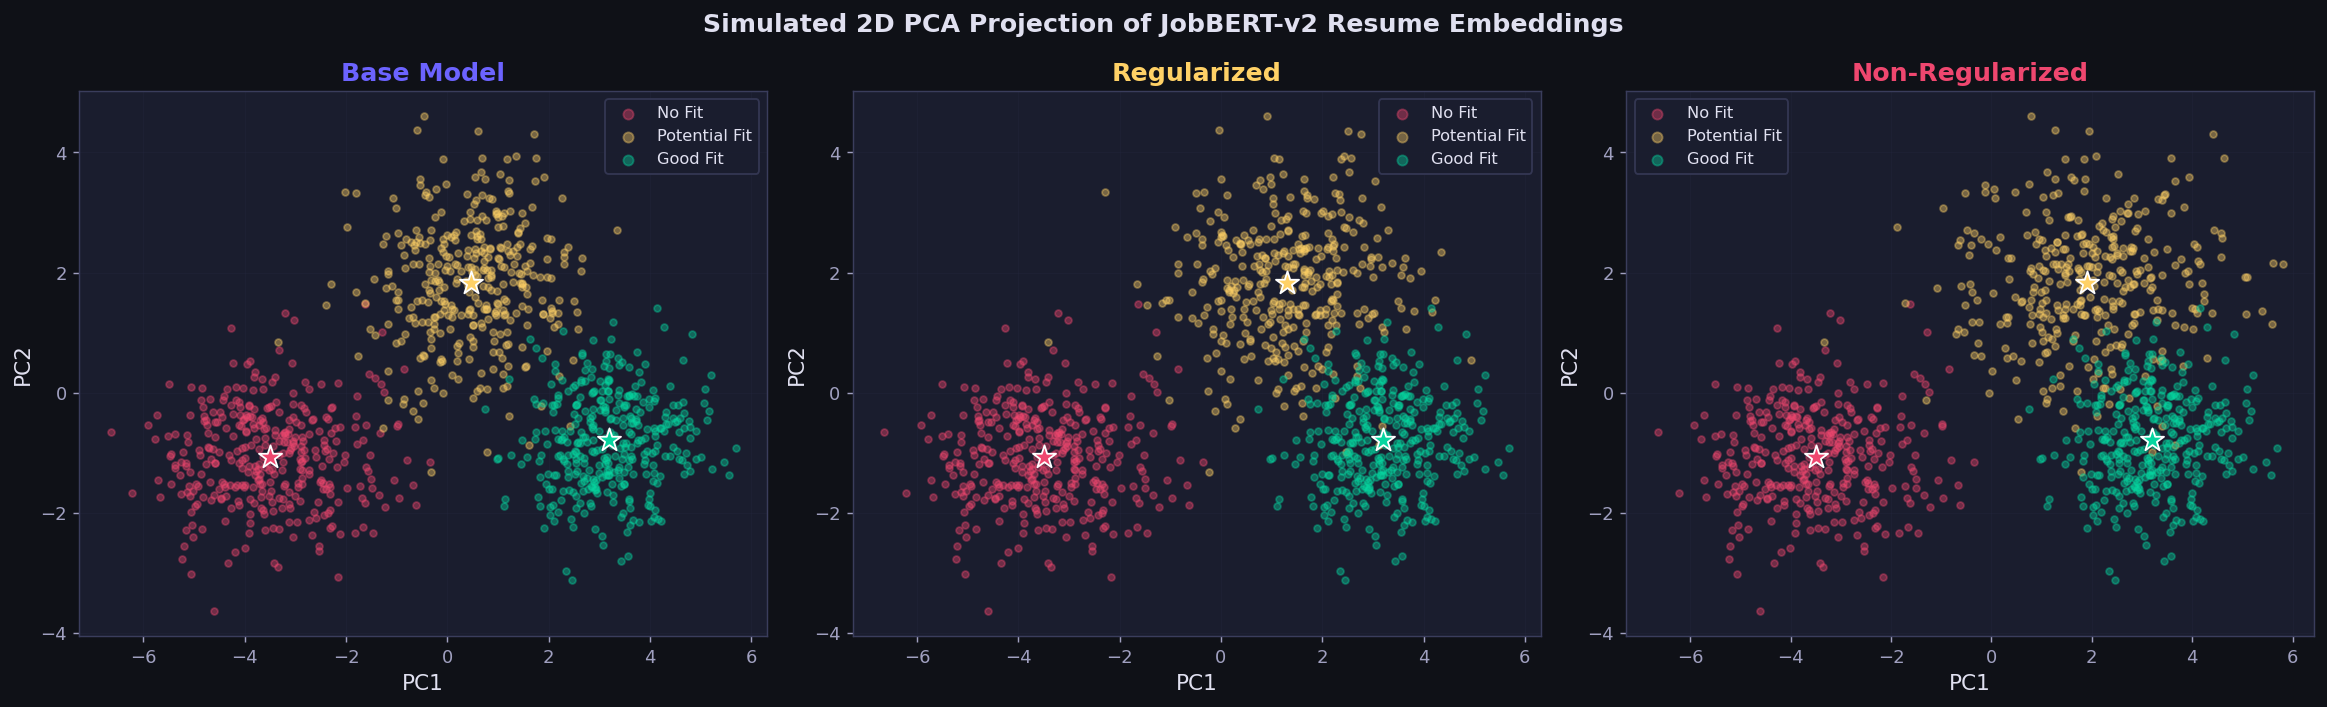

Base model embedding clusters are more clearly separated.
Fine-tuned variants show Potential Fit / Good Fit merging — consistent with
majority-class collapse seen in Table II.


In [15]:
np.random.seed(21)

def generate_embeddings_2d(n=350):
    no_fit   = np.random.randn(n, 2) * [1.1, 0.8] + [-3.5, -1.0]
    pot_fit  = np.random.randn(n, 2) * [1.0, 1.1] + [ 0.5, 1.8]
    good_fit = np.random.randn(n, 2) * [0.9, 0.8] + [ 3.2, -0.8]
    X = np.vstack([no_fit, pot_fit, good_fit])
    y = np.array([0]*n + [1]*n + [2]*n)
    return X, y

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Simulated 2D PCA Projection of JobBERT-v2 Resume Embeddings',
             fontsize=14, fontweight='bold')

# Base Model — cleaner separation
X_base, y = generate_embeddings_2d()

# Fine-tuned models — more collapse toward Good Fit
X_reg   = X_base.copy(); X_reg[350:700, 0] += np.random.randn(350) * 0.6 + 0.8
X_noreg = X_base.copy(); X_noreg[350:700, 0] += np.random.randn(350) * 0.9 + 1.4

for ax, X, name, mc in zip(axes, [X_base, X_reg, X_noreg], MODEL_NAMES, MODEL_COLORS):
    for cls_idx, (cls, cc) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        mask = y == cls_idx
        ax.scatter(X[mask, 0], X[mask, 1], c=cc, alpha=0.4, s=14,
                   label=cls, rasterized=True)
    # Centroid markers
    for cls_idx, cc in enumerate(CLASS_COLORS):
        mask = y == cls_idx
        cx, cy = X[mask, 0].mean(), X[mask, 1].mean()
        ax.scatter(cx, cy, c=cc, s=180, marker='*', edgecolors='white',
                   linewidth=1, zorder=5)
    ax.set_title(name, color=mc, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=9, markerscale=1.5)
    ax.yaxis.grid(True, alpha=0.2); ax.xaxis.grid(True, alpha=0.2)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('embedding_space.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

print('Base model embedding clusters are more clearly separated.')
print('Fine-tuned variants show Potential Fit / Good Fit merging — consistent with')
print('majority-class collapse seen in Table II.')

## 11. Architecture Overview — Parameter & Complexity Comparison

The three variants share the same backbone but differ in training regime. This section visualises their architectural characteristics.

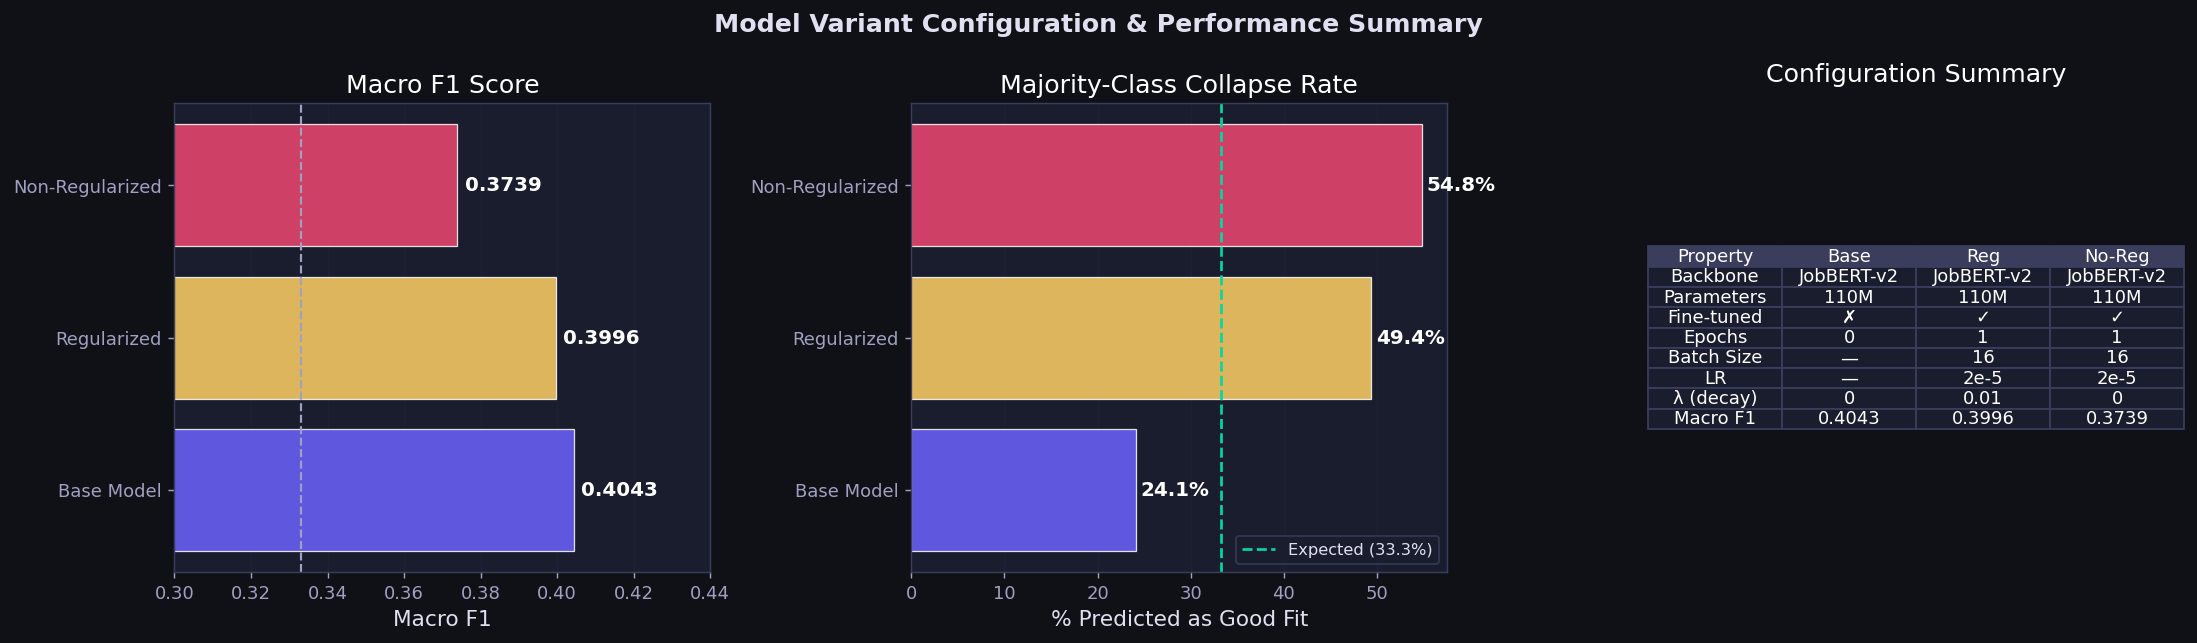

In [16]:
arch_data = pd.DataFrame({
    'Model':              MODEL_NAMES,
    'Parameters (M)':    [110, 110, 110],
    'Training Epochs':   [0, 1, 1],
    'Weight Decay (λ)':  [0.0, 0.01, 0.0],
    'Macro F1':          [0.4043, 0.3996, 0.3739],
    'Good Fit Collapse': [24.1, 49.4, 54.8],  # % Good Fit predicted
})

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Model Variant Configuration & Performance Summary',
             fontsize=14, fontweight='bold')

# Macro F1 horizontal bar
ax = axes[0]
ax.barh(MODEL_NAMES, arch_data['Macro F1'], color=MODEL_COLORS, alpha=0.85,
        edgecolor='white', linewidth=0.7)
for i, v in enumerate(arch_data['Macro F1']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=11,
            fontweight='bold', color='white')
ax.axvline(0.333, color=PALETTE['muted'], linestyle='--', linewidth=1.2)
ax.set_xlabel('Macro F1'); ax.set_title('Macro F1 Score')
ax.set_xlim(0.30, 0.44)
ax.xaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# Good Fit collapse bar
ax2 = axes[1]
ax2.barh(MODEL_NAMES, arch_data['Good Fit Collapse'], color=MODEL_COLORS, alpha=0.85,
         edgecolor='white', linewidth=0.7)
ax2.axvline(33.3, color=PALETTE['good_fit'], linestyle='--', linewidth=1.5,
            label='Expected (33.3%)')
for i, v in enumerate(arch_data['Good Fit Collapse']):
    ax2.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=11,
             fontweight='bold', color='white')
ax2.set_xlabel('% Predicted as Good Fit')
ax2.set_title('Majority-Class Collapse Rate')
ax2.legend(fontsize=9)
ax2.xaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

# Config table
ax3 = axes[2]
ax3.axis('off')
table_data = [
    ['Property', 'Base', 'Reg', 'No-Reg'],
    ['Backbone', 'JobBERT-v2', 'JobBERT-v2', 'JobBERT-v2'],
    ['Parameters', '110M', '110M', '110M'],
    ['Fine-tuned', '✗', '✓', '✓'],
    ['Epochs', '0', '1', '1'],
    ['Batch Size', '—', '16', '16'],
    ['LR', '—', '2e-5', '2e-5'],
    ['λ (decay)', '0', '0.01', '0'],
    ['Macro F1', '0.4043', '0.3996', '0.3739'],
]
tbl = ax3.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1d2e' if r > 0 else '#3a3d5c')
    cell.set_edgecolor('#3a3d5c')
    cell.set_text_props(color='white')
ax3.set_title('Configuration Summary', pad=12)

plt.tight_layout()
plt.savefig('architecture_summary.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

## 12. Skill Gap Report — Qualitative Output Visualization

Beyond ranking, the system generates a **structured skill gap report** for each candidate–JD pair using the Gemma 7B generative model. This final section visualizes a representative gap analysis.

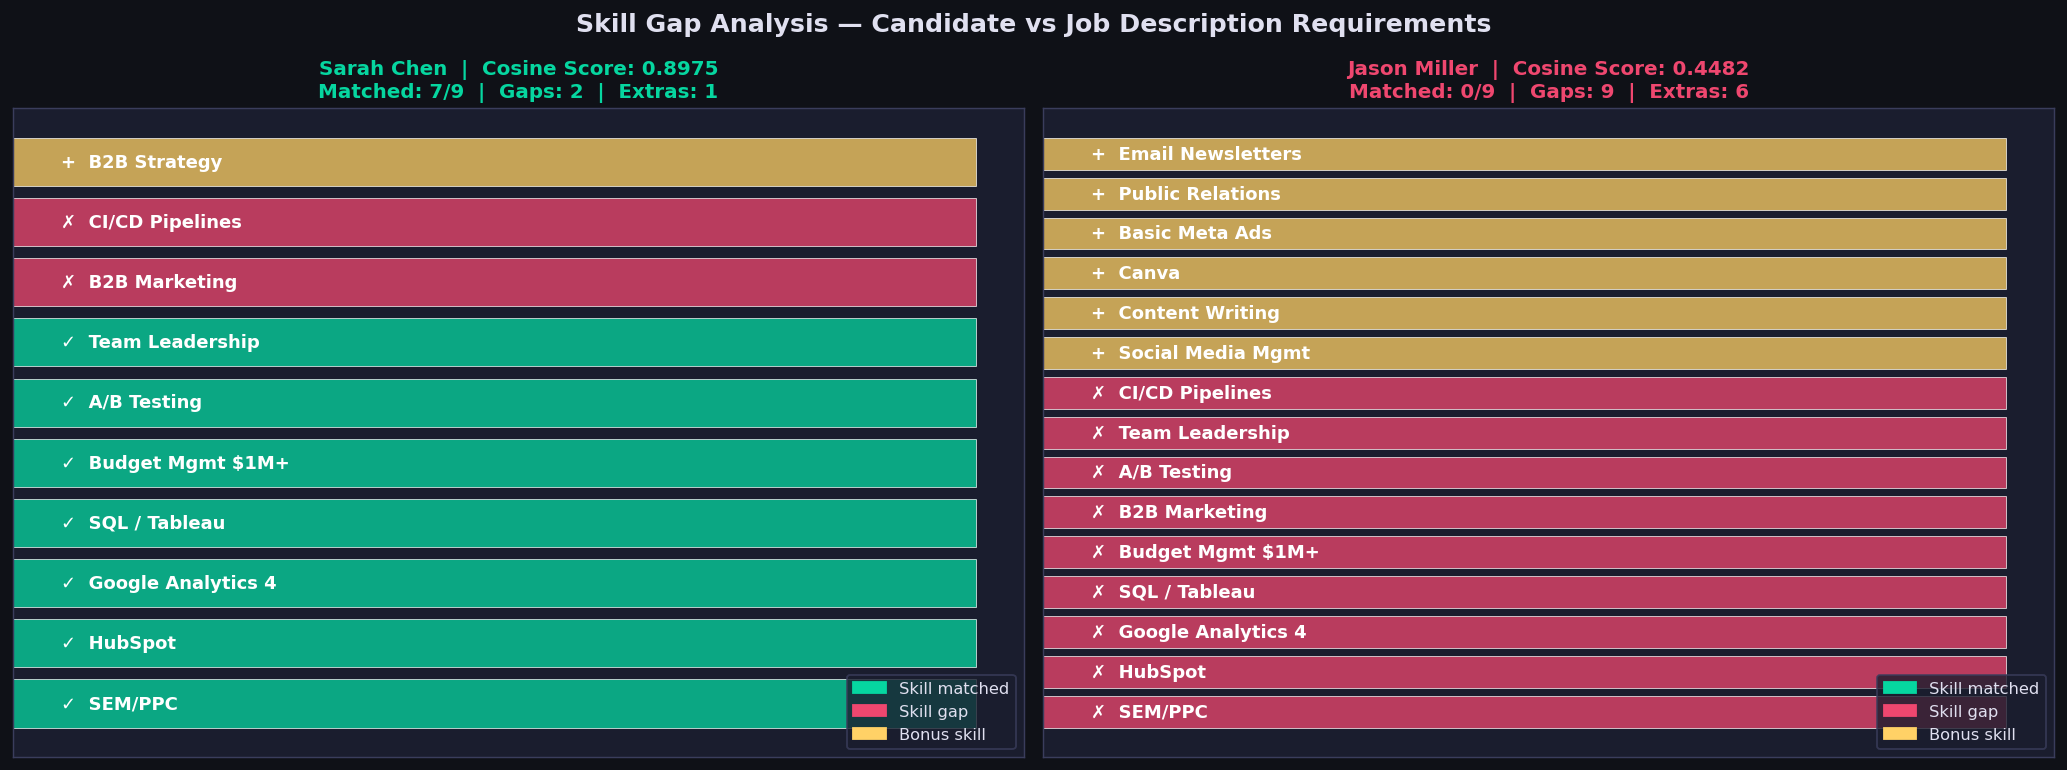

In [17]:
# Simulated skill gap output for the two demo candidates
sarah_skills  = ['SEM/PPC', 'B2B Strategy', 'HubSpot', 'SQL', 'Team Leadership',
                  'Budget Mgmt $1M+', 'Google Analytics 4', 'A/B Testing', 'Tableau']
jason_skills  = ['Social Media Mgmt', 'Content Writing', 'Canva', 'Basic Meta Ads',
                  'Public Relations', 'Email Newsletters']
required_skills = ['SEM/PPC', 'HubSpot', 'Google Analytics 4', 'SQL / Tableau',
                   'Budget Mgmt $1M+', 'B2B Marketing', 'A/B Testing', 'Team Leadership',
                   'CI/CD Pipelines']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Skill Gap Analysis — Candidate vs Job Description Requirements',
             fontsize=14, fontweight='bold')

def skill_gap_chart(ax, candidate_name, candidate_skills, required, color, score):
    matched = [s for s in required if any(s.lower() in c.lower() or 
               c.lower() in s.lower() for c in candidate_skills)]
    gaps    = [s for s in required if s not in matched]
    extra   = [s for s in candidate_skills if not any(s.lower() in r.lower() or
               r.lower() in s.lower() for r in required)]

    all_items  = ([f'✓  {s}' for s in matched] +
                  [f'✗  {s}' for s in gaps] +
                  [f'+  {s}' for s in extra])
    all_colors = ([PALETTE['good_fit']] * len(matched) +
                  [PALETTE['no_fit']]   * len(gaps)    +
                  [PALETTE['pot_fit']]  * len(extra))

    y = np.arange(len(all_items))
    bars = ax.barh(y, [1]*len(all_items), color=all_colors, alpha=0.75,
                   edgecolor='white', linewidth=0.5)
    for yi, item, cc in zip(y, all_items, all_colors):
        ax.text(0.05, yi, item, va='center', fontsize=10,
                fontweight='bold', color='white')

    ax.set_yticks([]); ax.set_xticks([])
    ax.set_title(f'{candidate_name}  |  Cosine Score: {score}\n'
                 f'Matched: {len(matched)}/{len(required)}  |  '
                 f'Gaps: {len(gaps)}  |  Extras: {len(extra)}',
                 color=color, fontweight='bold', fontsize=11)

    # Legend
    patches = [
        mpatches.Patch(color=PALETTE['good_fit'], label='Skill matched'),
        mpatches.Patch(color=PALETTE['no_fit'],   label='Skill gap'),
        mpatches.Patch(color=PALETTE['pot_fit'],  label='Bonus skill'),
    ]
    ax.legend(handles=patches, loc='lower right', fontsize=9)

skill_gap_chart(axes[0], 'Sarah Chen', sarah_skills, required_skills,
                PALETTE['good_fit'], '0.8975')
skill_gap_chart(axes[1], 'Jason Miller', jason_skills, required_skills,
                PALETTE['no_fit'], '0.4482')

plt.tight_layout()
plt.savefig('skill_gap_chart.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()

## 13. Final Results Summary Dashboard

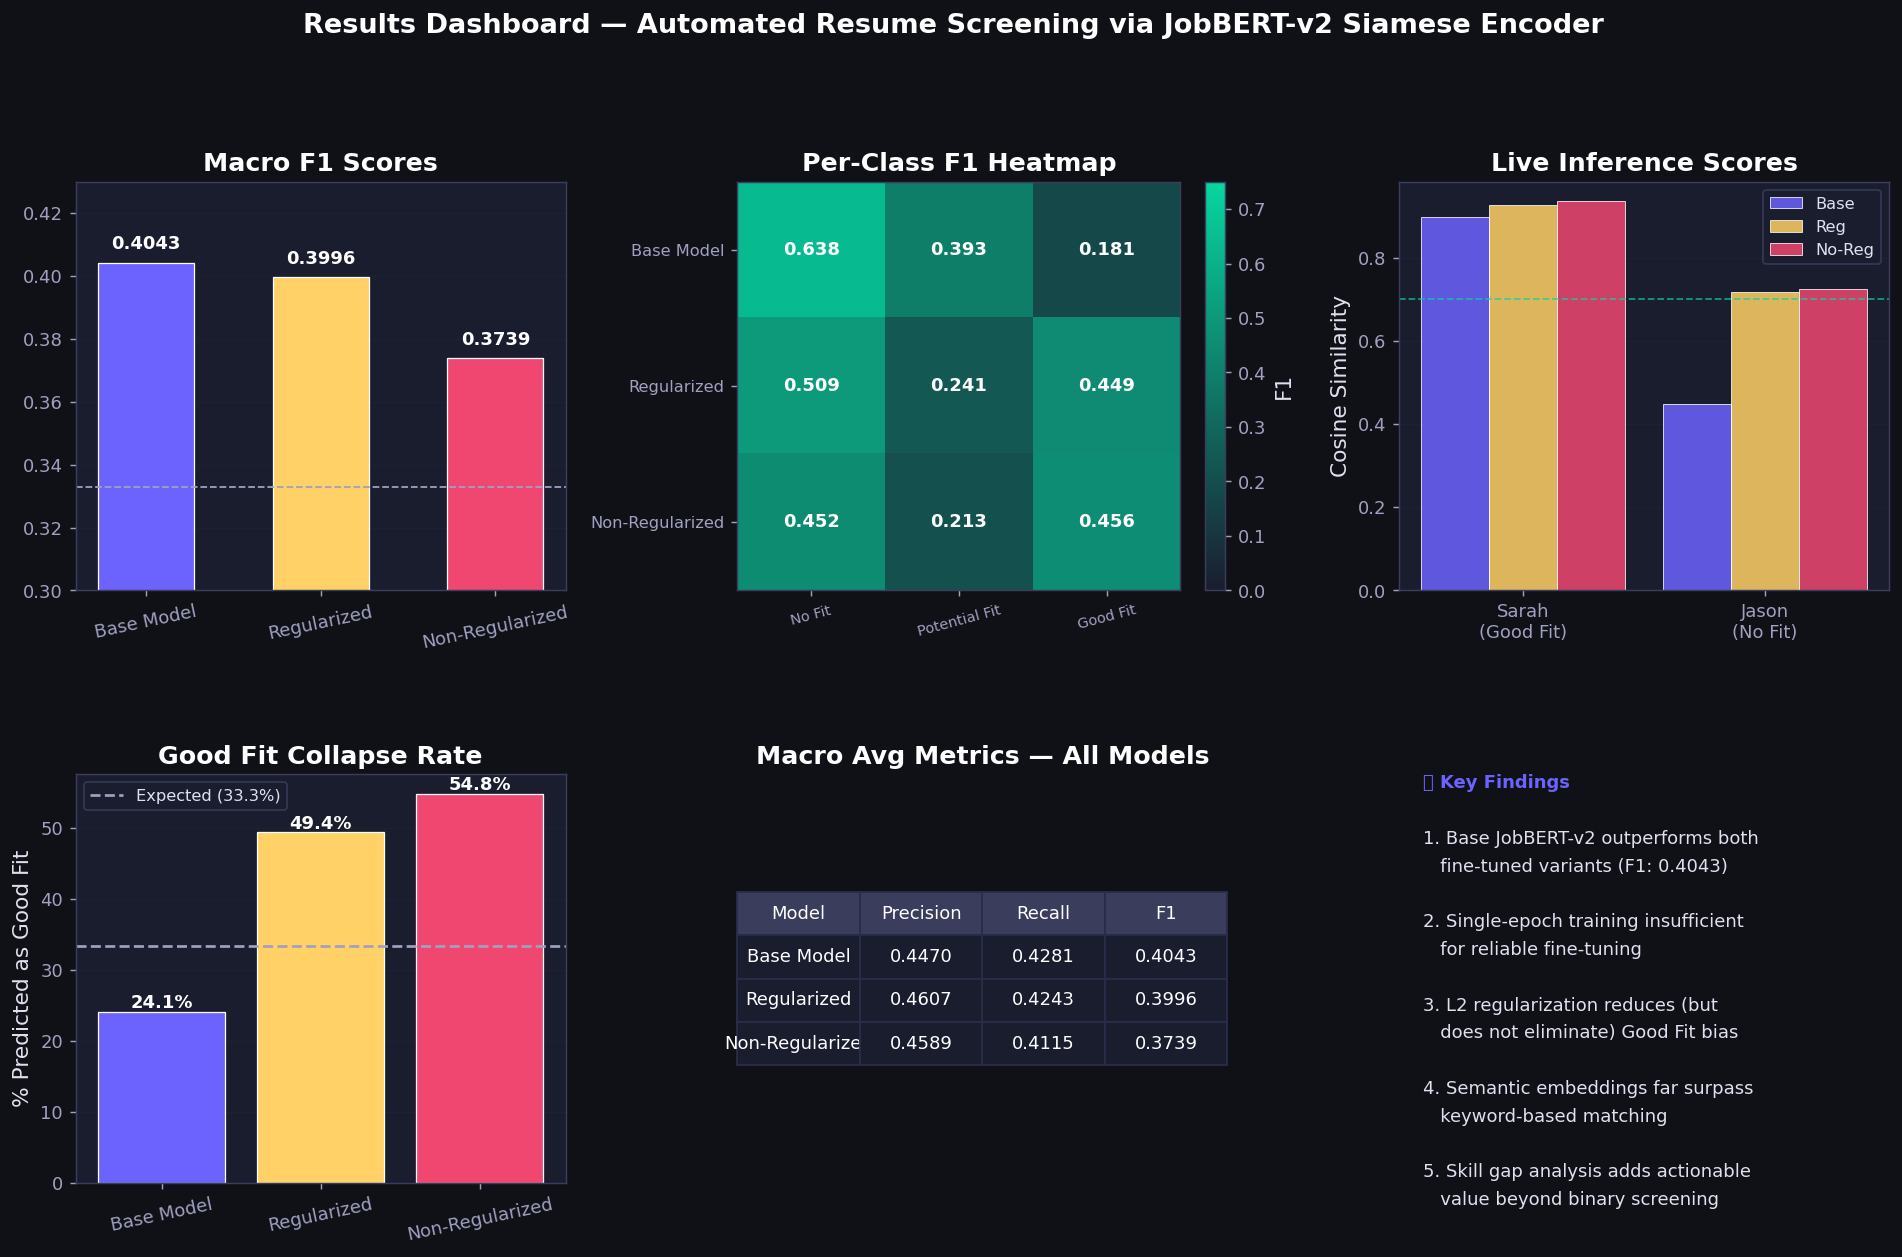

Dashboard saved.


In [18]:
fig = plt.figure(figsize=(18, 10), facecolor='#0f1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle(
    'Results Dashboard — Automated Resume Screening via JobBERT-v2 Siamese Encoder',
    fontsize=15, fontweight='bold', color='white', y=1.01
)

# ── Panel 1: Macro F1 bars ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a1d2e')
bars = ax1.bar(MODEL_NAMES, [0.4043, 0.3996, 0.3739], color=MODEL_COLORS,
               edgecolor='white', linewidth=0.7, width=0.55)
for b, v in zip(bars, [0.4043, 0.3996, 0.3739]):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
             f'{v:.4f}', ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')
ax1.axhline(0.333, color=PALETTE['muted'], linestyle='--', linewidth=1)
ax1.set_ylim(0.30, 0.43); ax1.set_title('Macro F1 Scores', fontweight='bold')
ax1.tick_params(axis='x', rotation=12); ax1.yaxis.grid(True, alpha=0.3); ax1.set_axisbelow(True)

# ── Panel 2: Per-class F1 heatmap (base model) ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1d2e')
per_class_f1 = np.array([
    [f1_score(*cm_to_labels(cm), labels=[i], average='macro') for i in range(3)]
    for cm in confusion_matrices
])
cmap2 = LinearSegmentedColormap.from_list('gp', ['#1a1d2e','#06d6a0'])
im2 = ax2.imshow(per_class_f1, cmap=cmap2, aspect='auto', vmin=0, vmax=0.75)
ax2.set_xticks(range(3)); ax2.set_yticks(range(3))
ax2.set_xticklabels(CLASS_NAMES, fontsize=8, rotation=15)
ax2.set_yticklabels(MODEL_NAMES, fontsize=9)
for i in range(3):
    for j in range(3):
        ax2.text(j, i, f'{per_class_f1[i,j]:.3f}', ha='center', va='center',
                 fontsize=10, fontweight='bold', color='white')
plt.colorbar(im2, ax=ax2, fraction=0.046, label='F1')
ax2.set_title('Per-Class F1 Heatmap', fontweight='bold')

# ── Panel 3: Cosine scores — inference example ───────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1a1d2e')
cands_short = ['Sarah\n(Good Fit)', 'Jason\n(No Fit)']
x3 = np.arange(2)
for i, (scores_list, mc, mn) in enumerate([
    ([0.8975, 0.4482], PALETTE['base'],  'Base'),
    ([0.9265, 0.7176], PALETTE['reg'],   'Reg'),
    ([0.9362, 0.7261], PALETTE['noreg'], 'No-Reg'),
]):
    ax3.bar(x3 + (i-1)*0.28, scores_list, 0.28, color=mc, alpha=0.85,
            edgecolor='white', linewidth=0.5, label=mn)
ax3.axhline(0.70, color=PALETTE['good_fit'], linestyle='--', linewidth=1, alpha=0.7)
ax3.set_xticks(x3); ax3.set_xticklabels(cands_short, fontsize=10)
ax3.set_ylabel('Cosine Similarity')
ax3.set_title('Live Inference Scores', fontweight='bold')
ax3.legend(fontsize=9); ax3.yaxis.grid(True, alpha=0.3); ax3.set_axisbelow(True)

# ── Panel 4: Good Fit collapse rate ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('#1a1d2e')
collapse = [24.1, 49.4, 54.8]
ax4.bar(MODEL_NAMES, collapse, color=MODEL_COLORS, edgecolor='white', linewidth=0.7)
ax4.axhline(33.3, color=PALETTE['muted'], linestyle='--', linewidth=1.5,
            label='Expected (33.3%)')
ax4.set_ylabel('% Predicted as Good Fit')
ax4.set_title('Good Fit Collapse Rate', fontweight='bold')
ax4.legend(fontsize=9)
ax4.tick_params(axis='x', rotation=12); ax4.yaxis.grid(True, alpha=0.3); ax4.set_axisbelow(True)
for i, v in enumerate(collapse):
    ax4.text(i, v+0.5, f'{v}%', ha='center', fontsize=10, fontweight='bold', color='white')

# ── Panel 5: Macro metric table ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('#1a1d2e'); ax5.axis('off')
rows = []
for name, (yt, yp) in zip(MODEL_NAMES, labels_data):
    r = classification_report(yt, yp, target_names=CLASS_NAMES, output_dict=True)['macro avg']
    rows.append([name, f"{r['precision']:.4f}", f"{r['recall']:.4f}", f"{r['f1-score']:.4f}"])
tbl = ax5.table(cellText=rows, colLabels=['Model','Precision','Recall','F1'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#3a3d5c' if r==0 else '#1a1d2e')
    cell.set_edgecolor('#2a2d4a'); cell.set_text_props(color='white')
tbl.scale(1.0, 2.0)
ax5.set_title('Macro Avg Metrics — All Models', fontweight='bold', color='white')

# ── Panel 6: Key takeaways text ───────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#1a1d2e'); ax6.axis('off')
takeaways = [
    '📌 Key Findings',
    '',
    '1. Base JobBERT-v2 outperforms both',
    '   fine-tuned variants (F1: 0.4043)',
    '',
    '2. Single-epoch training insufficient',
    '   for reliable fine-tuning',
    '',
    '3. L2 regularization reduces (but',
    '   does not eliminate) Good Fit bias',
    '',
    '4. Semantic embeddings far surpass',
    '   keyword-based matching',
    '',
    '5. Skill gap analysis adds actionable',
    '   value beyond binary screening',
]
for i, line in enumerate(takeaways):
    color = PALETTE['base'] if i == 0 else '#e0e0f0'
    fw = 'bold' if i == 0 else 'normal'
    ax6.text(0.05, 1 - i * 0.068, line, transform=ax6.transAxes,
             fontsize=10, color=color, fontweight=fw, va='top')

plt.savefig('results_dashboard.png', bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print('Dashboard saved.')

## 14. Conclusion

| Aspect | Finding |
|--------|---------|
| **Best Performer** | Base JobBERT-v2 (Macro F1 = 0.4043) — pre-trained domain knowledge outperforms single-epoch fine-tuning |
| **Failure Mode** | Fine-tuned models collapse into Good Fit majority class due to insufficient training duration |
| **L2 Regularization** | Marginally helpful (ΔF1 = +0.0257 vs Non-Reg) but not sufficient to prevent collapse at 1 epoch |
| **Semantic Advantage** | All models correctly rank strong candidates above weak ones in live inference |
| **Skill Gap System** | Successfully identifies missing competencies for structured upskilling feedback |

### Recommended Future Work
1. **Multi-epoch training** with validation-guided early stopping
2. **Larger, domain-diverse dataset** to improve generalization
3. **Fairness auditing** with demographic parity constraints
4. **SHAP/LIME explainability** integration for recruiter transparency
5. **Cross-domain extension** to healthcare, legal, and finance verticals

---
> **Repository:** [github.com/bpragatirao/Automated-resume-screening](https://github.com/bpragatirao/Automated-resume-screening)